# Hw5 - Customer Segmentation with Clustering Algorithms

## Question 1 - Data Loading & Optimal Cluster Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

%matplotlib inline

In [2]:
def load_and_explore(filepath):
    """Load the dataset from filepath and print exploratory information."""
    df = pd.read_csv(filepath)

    print("Shape:", df.shape)
    print("\nData types:\n", df.dtypes)
    print("\nMissing values per column:\n", df.isnull().sum())
    print("\nStats summary:\n", df.describe(include='all'))

    return df

In [3]:
filepath = "data/Mall_Customers.csv"
df = load_and_explore(filepath)
df.head()

Shape: (200, 5)

Data types:
 CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values per column:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Stats summary:
         CustomerID   Genre         Age  Annual Income (k$)  \
count   200.000000     200  200.000000          200.000000   
unique         NaN       2         NaN                 NaN   
top            NaN  Female         NaN                 NaN   
freq           NaN     112         NaN                 NaN   
mean    100.500000     NaN   38.850000           60.560000   
std      57.879185     NaN   13.969007           26.264721   
min       1.000000     NaN   18.000000           15.000000   
25%      50.750000     NaN   28.750000           41.500000   
50%     100.500000     NaN   36.00

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Q1b- Elbow Method

In [4]:
def find_optimal_k(X, k_range=range(1, 11)):
    wcss = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

    k_values = list(k_range)
    wcss = np.array(wcss)

    second_deriv = np.diff(wcss, 2)
    elbow_idx = np.argmax(second_deriv) + 1
    elbow_k = k_values[elbow_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, wcss, marker='o')
    plt.axvline(x=elbow_k, color='red', linestyle='--', label=f'Elbow at k={elbow_k}')
    plt.annotate(f'Elbow (k={elbow_k})',
                  xy=(elbow_k, wcss[elbow_idx]),
                  xytext=(elbow_k + 0.5, wcss[elbow_idx] + (wcss[0] - wcss[-1]) * 0.05),
                  arrowprops=dict(arrowstyle='->', color='red'))
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.legend()
    plt.show()

    print(f"Detected elbow point: k = {elbow_k}")
    return elbow_k

### Q1c - Silhouette Method

In [5]:
def find_optimal_k_silhouette(X, k_range=range(2, 11)):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)

    k_values = list(k_range)
    best_k = k_values[int(np.argmax(scores))]

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, scores, marker='o')
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    plt.title('Silhouette Score for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.show()

    print(f"Best k by silhouette score: k = {best_k}")
    return best_k

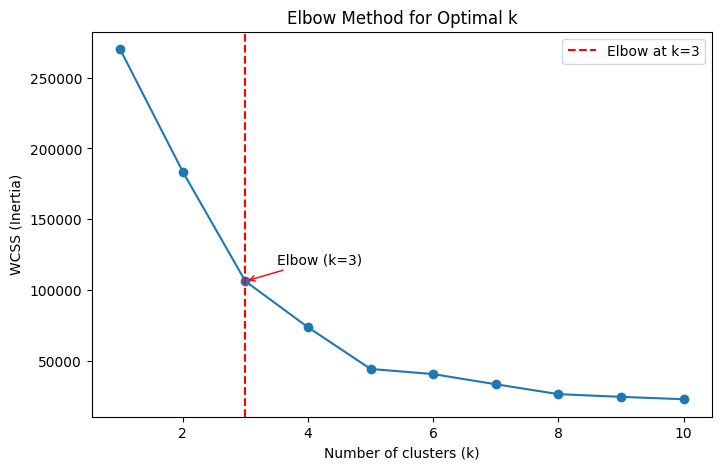

Detected elbow point: k = 3


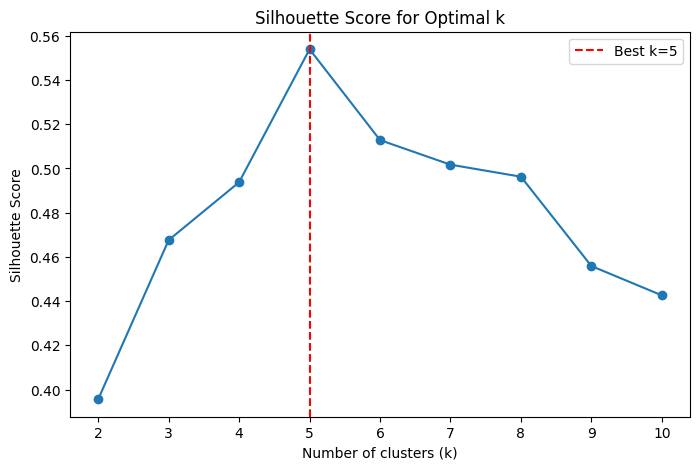

Best k by silhouette score: k = 5
Elbow method suggests k = 3
Silhouette method suggests k = 5

Optimal k chosen for the rest of the assignment: 5


In [6]:
# Use Annual Income and Spending Score for the initial cluster-count selection
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

elbow_k = find_optimal_k(X)
silhouette_k = find_optimal_k_silhouette(X)

print(f"Elbow method suggests k = {elbow_k}")
print(f"Silhouette method suggests k = {silhouette_k}")

"""Comparison: The elbow method detected k=3 as the point of sharpest curve
in the WCSS curve, while the silhouette method finds k=5 which gives the highest
score which higher than k=3 (~0.47). The two methods contradicts here,
the elbow curve is fairly gradual after k=3, so the second devrivate pick is less decisive,
whereas the silhouette score has a sharp peak at k=5, which also matches the 5 visually
distinct customer groups in the Income vs Spending Score scatter plot. We adopt k=5
as the optimal number of clusters for next steps"""
optimal_k = silhouette_k
print(f"\nOptimal k chosen for the rest of the assignment: {optimal_k}")

## Question 2 - K-Means Clustering Pipeline

### Q2a - Run K-Means & Plot Clusters

In [7]:
def run_kmeans(X, n_clusters, random_state=42):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=random_state)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_
    return kmeans, labels, centers

In [8]:
def plot_clusters(X, labels, title, centers=None, ax=None):
    """Dynamically scatter-plot points for any number of clusters, each with
    a unique color. If centers are provided, mark them distinctly. If ax is
    given, plot onto that axes (e.g. for a subplot grid); otherwise create a
    new figure."""
    unique_labels = np.unique(labels)
    cmap = plt.get_cmap('tab10')

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6))

    for i, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(X[mask, 0], X[mask, 1],
                   s=50, color=cmap(i % 10), label=f'Cluster {label}')

    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1],
                   s=250, c='black', marker='*', label='Centroids')

    ax.set_title(title)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.legend()

    if standalone:
        plt.show()

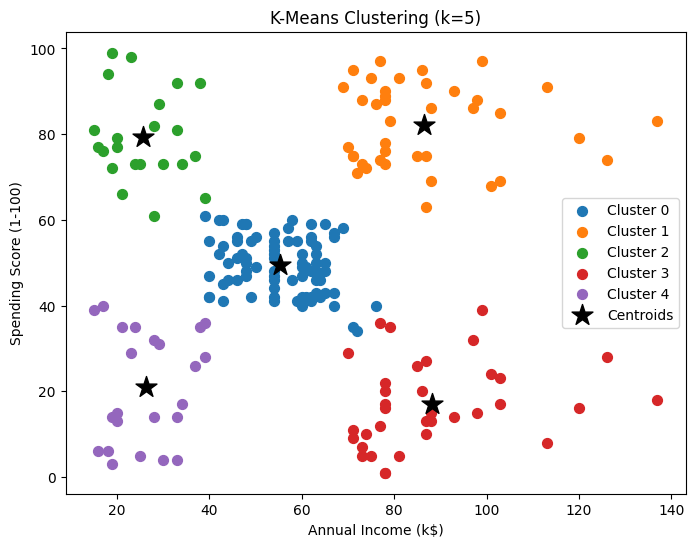

In [9]:
kmeans_model, kmeans_labels, kmeans_centers = run_kmeans(X, optimal_k)
plot_clusters(X, kmeans_labels, f'K-Means Clustering (k={optimal_k})', centers=kmeans_centers)

### Q2b - Cluster Profiling

In [10]:
def profile_clusters(df, labels):
    profiled = df.copy()
    profiled['Cluster'] = labels

    summary_rows = []
    for cluster_id, group in profiled.groupby('Cluster'):
        gender_pct = group['Genre'].value_counts(normalize=True) * 100
        summary_rows.append({
            'Cluster': cluster_id,
            'Count': len(group),
            'Mean Age': group['Age'].mean(),
            'Mean Annual Income (k$)': group['Annual Income (k$)'].mean(),
            'Mean Spending Score': group['Spending Score (1-100)'].mean(),
            '% Male': gender_pct.get('Male', 0.0),
            '% Female': gender_pct.get('Female', 0.0),
        })

    summary = pd.DataFrame(summary_rows).set_index('Cluster')
    print(summary)
    return summary

In [11]:
cluster_summary = profile_clusters(df, kmeans_labels)

         Count   Mean Age  Mean Annual Income (k$)  Mean Spending Score  \
Cluster                                                                   
0           81  42.716049                55.296296            49.518519   
1           39  32.692308                86.538462            82.128205   
2           22  25.272727                25.727273            79.363636   
3           35  41.114286                88.200000            17.114286   
4           23  45.217391                26.304348            20.913043   

            % Male   % Female  
Cluster                        
0        40.740741  59.259259  
1        46.153846  53.846154  
2        40.909091  59.090909  
3        54.285714  45.714286  
4        39.130435  60.869565  


### Q2c — Stability Test

In [12]:
def kmeans_stability_test(X, n_clusters, n_runs=10):
    all_labels = []
    for rs in range(n_runs):
        kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=rs)
        labels = kmeans.fit_predict(X)
        all_labels.append(labels)

    reference = all_labels[0]
    ari_scores = [adjusted_rand_score(reference, labels) for labels in all_labels]

    mean_ari = np.mean(ari_scores)
    std_ari = np.std(ari_scores)

    print(f"ARI scores (vs run 0): {[round(s, 4) for s in ari_scores]}")
    print(f"Mean ARI: {mean_ari:.4f}")
    print(f"Std ARI:  {std_ari:.4f}")

    """Discussion: Mean ARI = 0.9661, Std ARI = 0.0917. 8 of 10 runs gave
    ARI >= 0.98 vs run 0, which means those runs produced the same partition. 
    Run 4 dropped to ARI = 0.6915,indicating k-means++ converged to a different 
    local optimum for that seed. Overall the clustering is largely stable but it is not
    perfectly stable, since K-Means can still land in a different local
    minimum for some initializations."""

    return mean_ari, std_ari

In [13]:
mean_ari, std_ari = kmeans_stability_test(X, optimal_k, n_runs=10)

ARI scores (vs run 0): [1.0, 1.0, 1.0, 0.9847, 0.6915, 0.9847, 1.0, 1.0, 1.0, 1.0]
Mean ARI: 0.9661
Std ARI:  0.0917


## Question 3- Hierarchical Clustering Pipeline

### Q3a - Dendrogram

In [14]:
def plot_dendrogram(X, method='ward'):
    Z = linkage(X, method=method)
    merge_distances = Z[:, 2]
    cut_height = merge_distances[-(optimal_k - 1)]
    if len(merge_distances) >= optimal_k:
        next_merge = merge_distances[-optimal_k]
        cut_height = (cut_height + next_merge) / 2

    plt.figure(figsize=(10, 6))
    dendrogram(Z, truncate_mode='lastp', p=30)
    plt.axhline(y=cut_height, color='red', linestyle='--',
                label=f'Cut for {optimal_k} clusters')
    plt.title(f'Dendrogram ({method} linkage, truncated to last 30 merges)')
    plt.xlabel('Cluster size (or sample index)')
    plt.ylabel('Distance')
    plt.legend()
    plt.show()

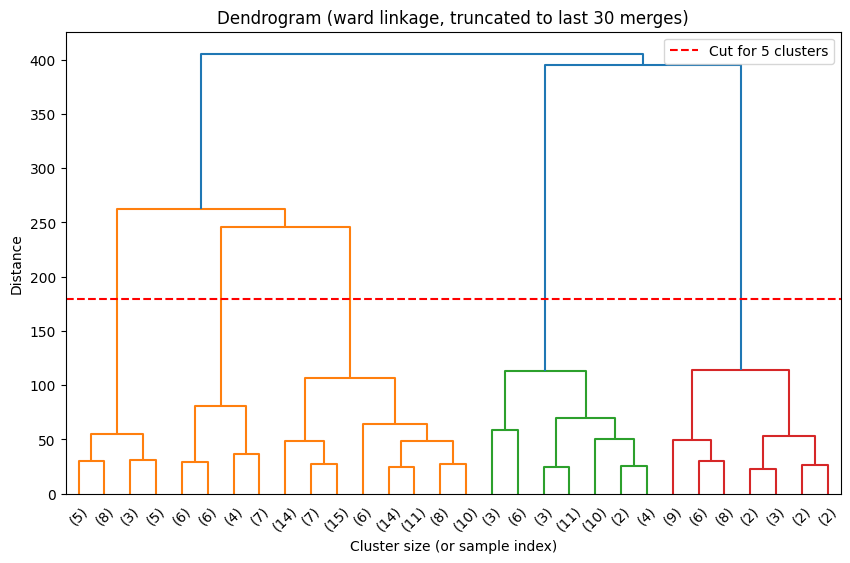

In [15]:
plot_dendrogram(X, method='ward')

### Q3b - Compare Linkage Methods

In [16]:
def compare_linkage_methods(X, n_clusters, methods=['ward', 'complete', 'average', 'single']):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    results = []
    for ax, method in zip(axes, methods):
        hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=method)
        labels = hc.fit_predict(X)
        score = silhouette_score(X, labels)
        results.append({'Linkage Method': method, 'Silhouette Score': score})
        plot_clusters(X, labels, f'{method.capitalize()} Linkage', centers=None, ax=ax)

    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame(results)
    print(summary)
    return summary

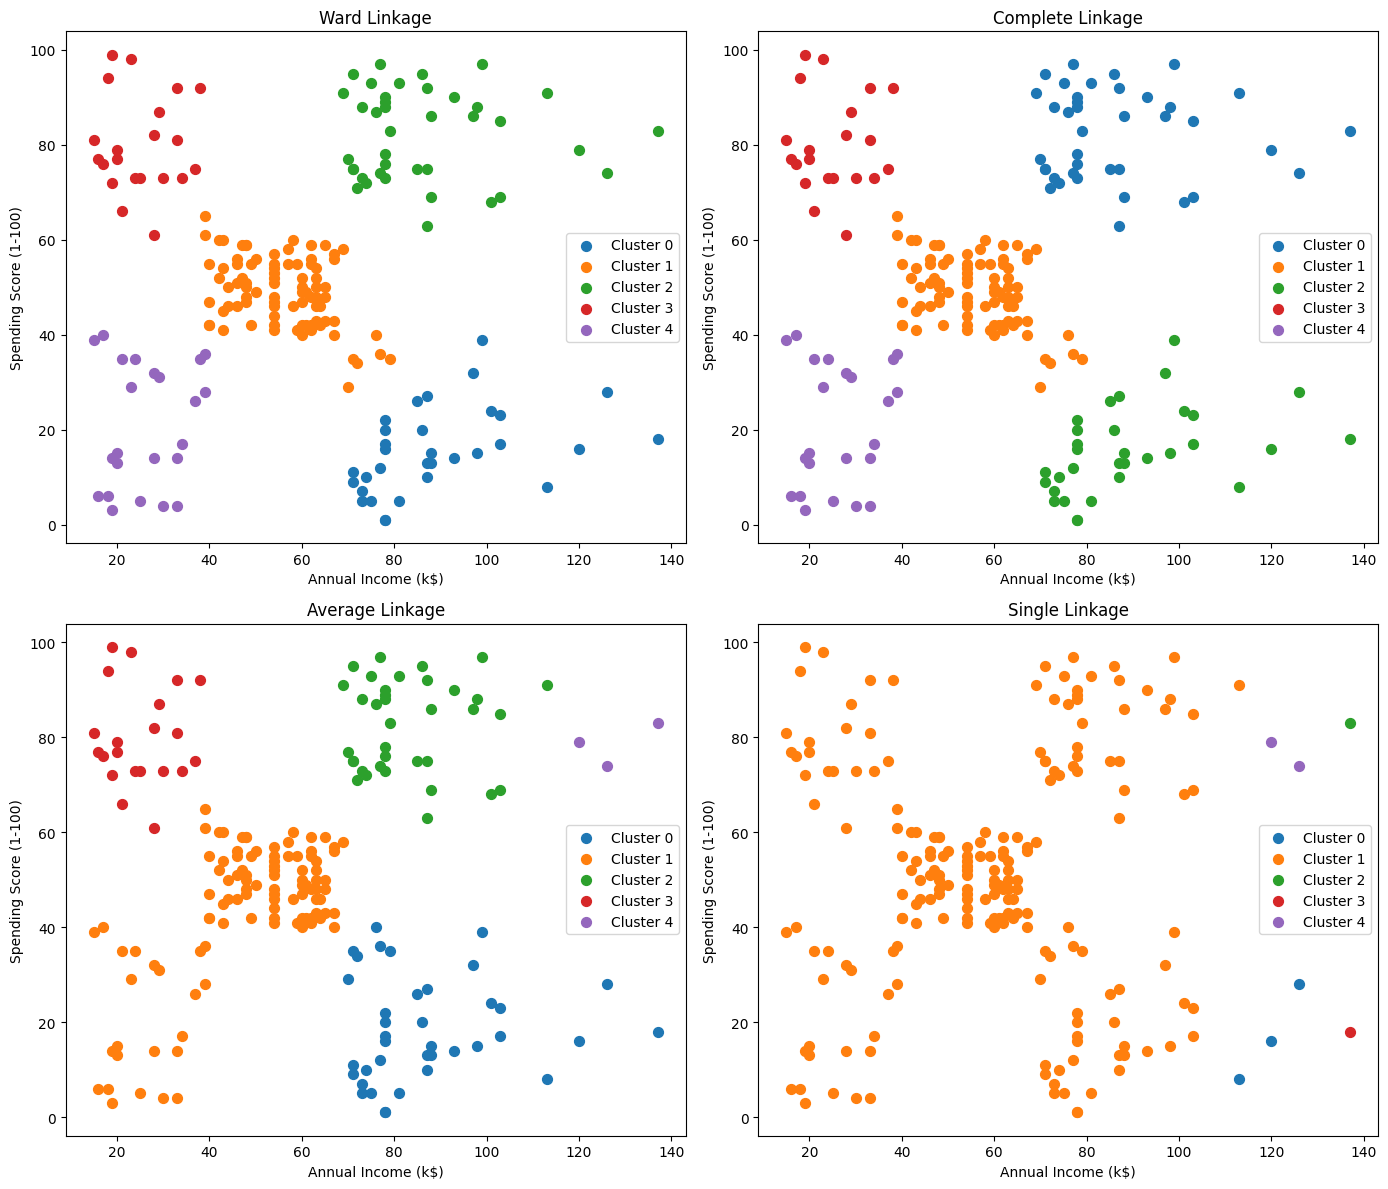

  Linkage Method  Silhouette Score
0           ward          0.552995
1       complete          0.552995
2        average          0.479191
3         single          0.269490


In [17]:
linkage_summary = compare_linkage_methods(X, optimal_k)

### Q3c - K-Means vs Hierarchical

In [18]:
def compare_kmeans_vs_hierarchical(X, n_clusters):
    """Run K-Means and Agglomerative (ward) clustering with the same
    n_clusters, plot both side-by-side, compute the ARI between their
    labels, and print silhouette scores for each."""
    _, kmeans_labels, kmeans_centers = run_kmeans(X, n_clusters)

    hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
    hc_labels = hc.fit_predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_clusters(X, kmeans_labels, 'K-Means', centers=kmeans_centers, ax=axes[0])
    plot_clusters(X, hc_labels, 'Agglomerative (Ward)', centers=None, ax=axes[1])
    plt.tight_layout()
    plt.show()

    ari = adjusted_rand_score(kmeans_labels, hc_labels)
    kmeans_sil = silhouette_score(X, kmeans_labels)
    hc_sil = silhouette_score(X, hc_labels)

    print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}")
    print(f"K-Means silhouette score: {kmeans_sil:.4f}")
    print(f"Hierarchical (Ward) silhouette score: {hc_sil:.4f}")

    """With ARI = 0.9420, K-Means and Ward-linkage hierarchical
    clustering produce nearly identical partitions on this dataset, since both methods
    minimize within-cluster variance and the 5 customer groups are well
    separated. K-Means edges out slightly on silhouette score (0.5539 vs
    0.5530), might be cause it directly optimizes centroid based
    compactness via iterative reassignment, whereas hierarchical
    clustering is constrained by its greedy, irreversible bottom-up merge
    order. The difference is small enough that either algorithm performs
    well here."""

    return ari, kmeans_sil, hc_sil

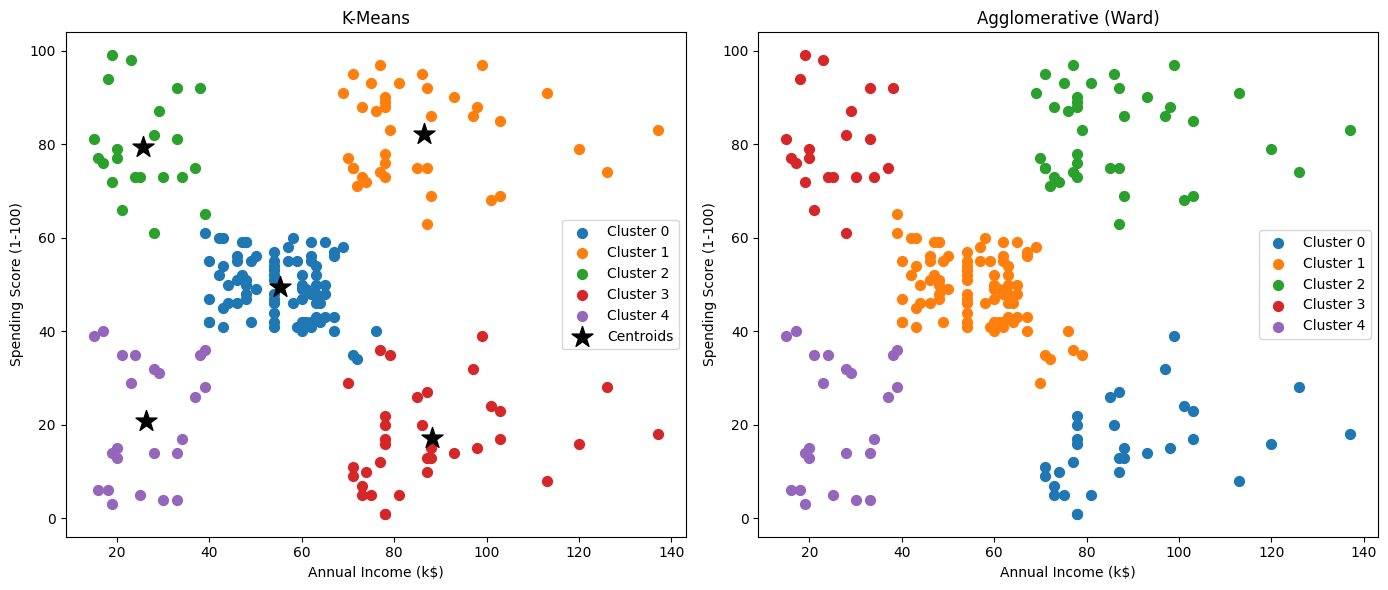

Adjusted Rand Index (K-Means vs Hierarchical): 0.9420
K-Means silhouette score: 0.5539
Hierarchical (Ward) silhouette score: 0.5530


In [19]:
comparison_ari, kmeans_sil, hc_sil = compare_kmeans_vs_hierarchical(X, optimal_k)

## Question 4 - Extended Feature Analysis

### Q4a - Prepare Features

In [20]:
def prepare_features(df, feature_cols, scale=True):
    """Build a feature matrix from feature_cols. Categorical columns are
    one-hot encoded first; if scale is True, StandardScaler is then applied
    to all resulting numerical columns. Returns (X, encoder, scaler), where
    encoder/scaler are None if not used."""
    data = df[feature_cols]

    categorical_cols = data.select_dtypes(include='object').columns.tolist()
    numerical_cols = data.select_dtypes(exclude='object').columns.tolist()

    encoder = None
    parts = []

    if categorical_cols:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = encoder.fit_transform(data[categorical_cols])
        parts.append(encoded)

    if numerical_cols:
        parts.append(data[numerical_cols].values.astype(float))

    X = np.hstack(parts) if len(parts) > 1 else parts[0]

    scaler = None
    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    return X, encoder, scaler

In [21]:
# Three feature sets to demonstrate prepare_features
feature_sets = {
    'Income + Spending': ['Annual Income (k$)', 'Spending Score (1-100)'],
    'Age + Income + Spending': ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    'All features (incl. Genre)': ['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
}

prepared = {}
for name, cols in feature_sets.items():
    X_feat, encoder, scaler = prepare_features(df, cols, scale=True)
    prepared[name] = {'X': X_feat, 'cols': cols, 'encoder': encoder, 'scaler': scaler}
    print(f"{name}: feature matrix shape = {X_feat.shape}")

Income + Spending: feature matrix shape = (200, 2)
Age + Income + Spending: feature matrix shape = (200, 3)
All features (incl. Genre): feature matrix shape = (200, 5)


### Q4b - Cluster & Visualize Each Feature Set

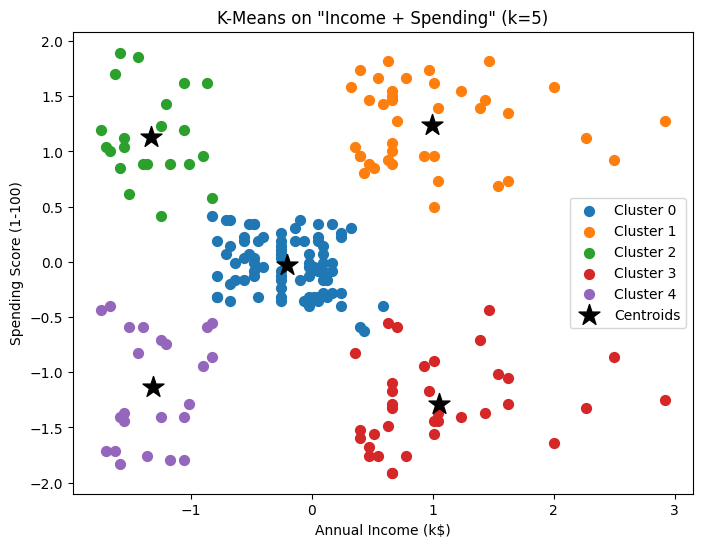

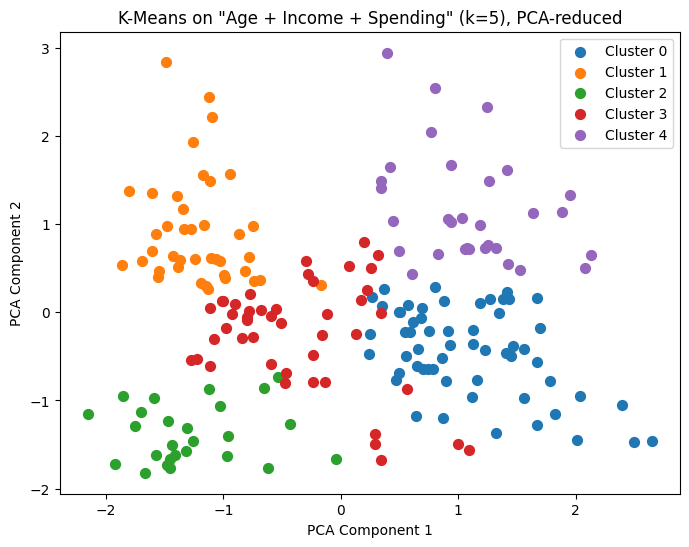

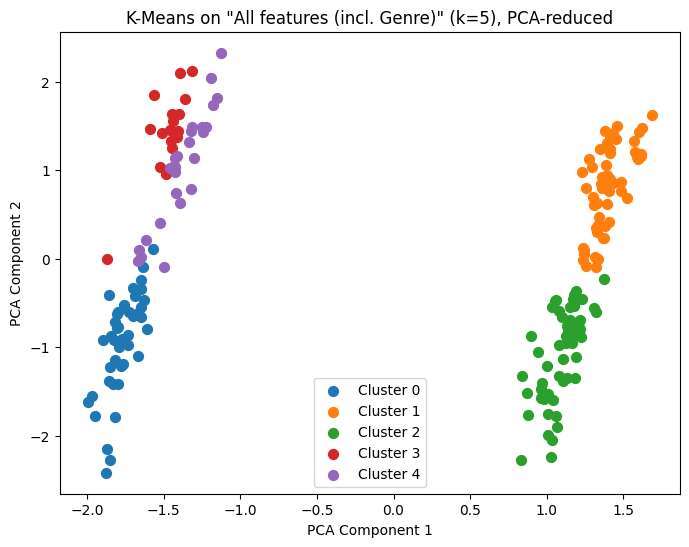

                  Feature Set  Silhouette Score
0           Income + Spending          0.554657
1     Age + Income + Spending          0.408469
2  All features (incl. Genre)          0.339383


In [22]:
feature_set_results = []
fitted_models = {}

for name, info in prepared.items():
    X_feat = info['X']
    model, labels, centers = run_kmeans(X_feat, optimal_k)
    score = silhouette_score(X_feat, labels)
    feature_set_results.append({'Feature Set': name, 'Silhouette Score': score})
    fitted_models[name] = {'model': model, 'labels': labels}

    if X_feat.shape[1] == 2:
        plot_clusters(X_feat, labels, f'K-Means on "{name}" (k={optimal_k})', centers=centers)
    else:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_feat)
        plt.figure(figsize=(8, 6))
        cmap = plt.get_cmap('tab10')
        for i, label in enumerate(np.unique(labels)):
            mask = labels == label
            plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=50, color=cmap(i % 10), label=f'Cluster {label}')
        plt.title(f'K-Means on "{name}" (k={optimal_k}), PCA-reduced')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend()
        plt.show()

feature_set_summary = pd.DataFrame(feature_set_results)
print(feature_set_summary)

### Q4c - Predict New Customers

In [23]:
def predict_new_customers(model, encoder, scaler, new_data):
    categorical_cols = new_data.select_dtypes(include='object').columns.tolist()
    numerical_cols = new_data.select_dtypes(exclude='object').columns.tolist()

    parts = []
    if encoder is not None and categorical_cols:
        parts.append(encoder.transform(new_data[categorical_cols]))
    if numerical_cols:
        parts.append(new_data[numerical_cols].values.astype(float))

    X_new = np.hstack(parts) if len(parts) > 1 else parts[0]

    if scaler is not None:
        X_new = scaler.transform(X_new)

    predicted_clusters = model.predict(X_new)

    for i, (_, row) in enumerate(new_data.iterrows()):
        cluster_id = predicted_clusters[i]
        print(f"\nNew customer: {row.to_dict()}")
        print(f"Assigned cluster: {cluster_id}")
        print("Cluster profile:")
        print(cluster_summary.loc[cluster_id])

    return predicted_clusters

In [24]:
new_customers = pd.DataFrame({
    'Annual Income (k$)': [80, 90, 30],
    'Spending Score (1-100)': [85, 15, 75],
})

income_spending_info = prepared['Income + Spending']
income_spending_model = fitted_models['Income + Spending']['model']

predicted_clusters = predict_new_customers(
    income_spending_model,
    income_spending_info['encoder'],
    income_spending_info['scaler'],
    new_customers
)


New customer: {'Annual Income (k$)': 80, 'Spending Score (1-100)': 85}
Assigned cluster: 1
Cluster profile:
Count                      39.000000
Mean Age                   32.692308
Mean Annual Income (k$)    86.538462
Mean Spending Score        82.128205
% Male                     46.153846
% Female                   53.846154
Name: 1, dtype: float64

New customer: {'Annual Income (k$)': 90, 'Spending Score (1-100)': 15}
Assigned cluster: 3
Cluster profile:
Count                      35.000000
Mean Age                   41.114286
Mean Annual Income (k$)    88.200000
Mean Spending Score        17.114286
% Male                     54.285714
% Female                   45.714286
Name: 3, dtype: float64

New customer: {'Annual Income (k$)': 30, 'Spending Score (1-100)': 75}
Assigned cluster: 2
Cluster profile:
Count                      22.000000
Mean Age                   25.272727
Mean Annual Income (k$)    25.727273
Mean Spending Score        79.363636
% Male                     40.909